# **EXP B - 01: NeuralLW offline**

## **0. Setup**

In [168]:
# Load packages
using Revise
using NeuralLongwave

In [169]:
# Define experiments and general settings
EXP = "exp_B"
SER = "01_NLW_MLP_offline"

# Define units
BASELINES = ["b_OBLW"]
UNITS = ["$(f)_w$(lpad(w, 3, '0'))_h$(d)" for f in ("direct", "linear", "planck") for w in (32, 64, 128) for d in 1:3];

In [170]:
# Load all weather and climate rollouts and timings
w = collect_rollouts(EXP, SER, [BASELINES..., UNITS...], leg = :weather)
c = collect_rollouts(EXP, SER, UNITS; leg = :climate)
t = load_timings(EXP, SER);

In [171]:
# Reference rollouts of the target (generated once by scripts/targets/OBLW/03_reference.jl)
clim_ref    = load_reference("OBLW", "climate_ref", "climate.jld2")
clim_noise  = load_reference("OBLW", "climate_noise", "climate.jld2");

In [172]:
# Define looks
ms_base = 15
w1 = ms_base
w2 = 1.5*w1
w3 = 1.5*w2

looks_costplane = (;
    b_OBLW         = (; label = "OBLW",    color = :black, marker = :star5),

    direct_w032_h1 = (; label="Direct H1", color=JL_BLUE,  marker=:circle, markersize=w1, group=:w32h1),
    direct_w032_h2 = (; label="Direct H2", color=JL_BLUE,  marker=:diamond, markersize=w1, group=:w32h2),
    direct_w032_h3 = (; label="Direct H3", color=JL_BLUE,  marker=:rect, markersize=w1, group=:w32h3),

    direct_w064_h1 = (; label="Direct H1", color=JL_BLUE,  marker=:circle, markersize=w2, group=:w64h1),
    direct_w064_h2 = (; label="Direct H2", color=JL_BLUE,  marker=:diamond, markersize=w2, group=:w64h2),
    direct_w064_h3 = (; label="Direct H3", color=JL_BLUE,  marker=:rect, markersize=w2, group=:w64h3),

    direct_w128_h1 = (; label="Direct H1", color=JL_BLUE,  marker=:circle, markersize=w3, group=:w128h1),
    direct_w128_h2 = (; label="Direct H2", color=JL_BLUE,  marker=:diamond, markersize=w3, group=:w128h2),
    direct_w128_h3 = (; label="Direct H3", color=JL_BLUE,  marker=:rect, markersize=w3, group=:w128h3),


    linear_w032_h1 = (; label="Linear H1", color=JL_GREEN,  marker=:circle, markersize=w1, group=:w32h1),
    linear_w032_h2 = (; label="Linear H2", color=JL_GREEN,  marker=:diamond, markersize=w1, group=:w32h2),
    linear_w032_h3 = (; label="Linear H3", color=JL_GREEN,  marker=:rect, markersize=w1, group=:w32h3),

    linear_w064_h1 = (; label="Linear H1", color=JL_GREEN,  marker=:circle, markersize=w2, group=:w64h1),
    linear_w064_h2 = (; label="Linear H2", color=JL_GREEN,  marker=:diamond, markersize=w2, group=:w64h2),
    linear_w064_h3 = (; label="Linear H3", color=JL_GREEN,  marker=:rect, markersize=w2, group=:w64h3),

    linear_w128_h1 = (; label="Linear H1", color=JL_GREEN,  marker=:circle, markersize=w3, group=:w128h1),
    linear_w128_h2 = (; label="Linear H2", color=JL_GREEN,  marker=:diamond, markersize=w3, group=:w128h2),
    linear_w128_h3 = (; label="Linear H3", color=JL_GREEN,  marker=:rect, markersize=w3, group=:w128h3),


    planck_w032_h1 = (; label="Planck H1", color=JL_RED,  marker=:circle, markersize=w1, group=:w32h1),
    planck_w032_h2 = (; label="Planck H2", color=JL_RED,  marker=:diamond, markersize=w1, group=:w32h2),
    planck_w032_h3 = (; label="Planck H3", color=JL_RED,  marker=:rect, markersize=w1, group=:w32h3),

    planck_w064_h1 = (; label="Planck H1", color=JL_RED,  marker=:circle, markersize=w2, group=:w64h1),
    planck_w064_h2 = (; label="Planck H2", color=JL_RED,  marker=:diamond, markersize=w2, group=:w64h2),
    planck_w064_h3 = (; label="Planck H3", color=JL_RED,  marker=:rect, markersize=w2, group=:w64h3),

    planck_w128_h1 = (; label="Planck H1", color=JL_RED,  marker=:circle, markersize=w3, group=:w128h1),
    planck_w128_h2 = (; label="Planck H2", color=JL_RED,  marker=:diamond, markersize=w3, group=:w128h2),
    planck_w128_h3 = (; label="Planck H3", color=JL_RED,  marker=:rect, markersize=w3, group=:w128h3),
);

## **1. Training**

In [173]:
summarize_series(EXP, SER; by = :loss_total, n_ep = 5, tol = 0.015)

Row,unit,loss_total,settled,converged,pct
,String,Float64,Int64,Bool,Float64
1,planck_w064_h2,0.000509426,55,true,0.0
2,planck_w064_h3,0.000525588,55,true,3.2
3,linear_w128_h2,0.00055522,55,true,9.0
4,planck_w128_h2,0.000557064,55,true,9.4
5,linear_w064_h3,0.000559707,55,true,9.9
6,planck_w128_h3,0.000570561,56,true,12.0
7,linear_w064_h2,0.000583714,55,true,14.6
8,linear_w128_h3,0.000597341,56,true,17.3
9,planck_w032_h3,0.000794642,54,true,56.0


## **2. Weather Cost Plane**

In [174]:
# Create tables
wt = weather_table(w)
tt = timing_table(t);

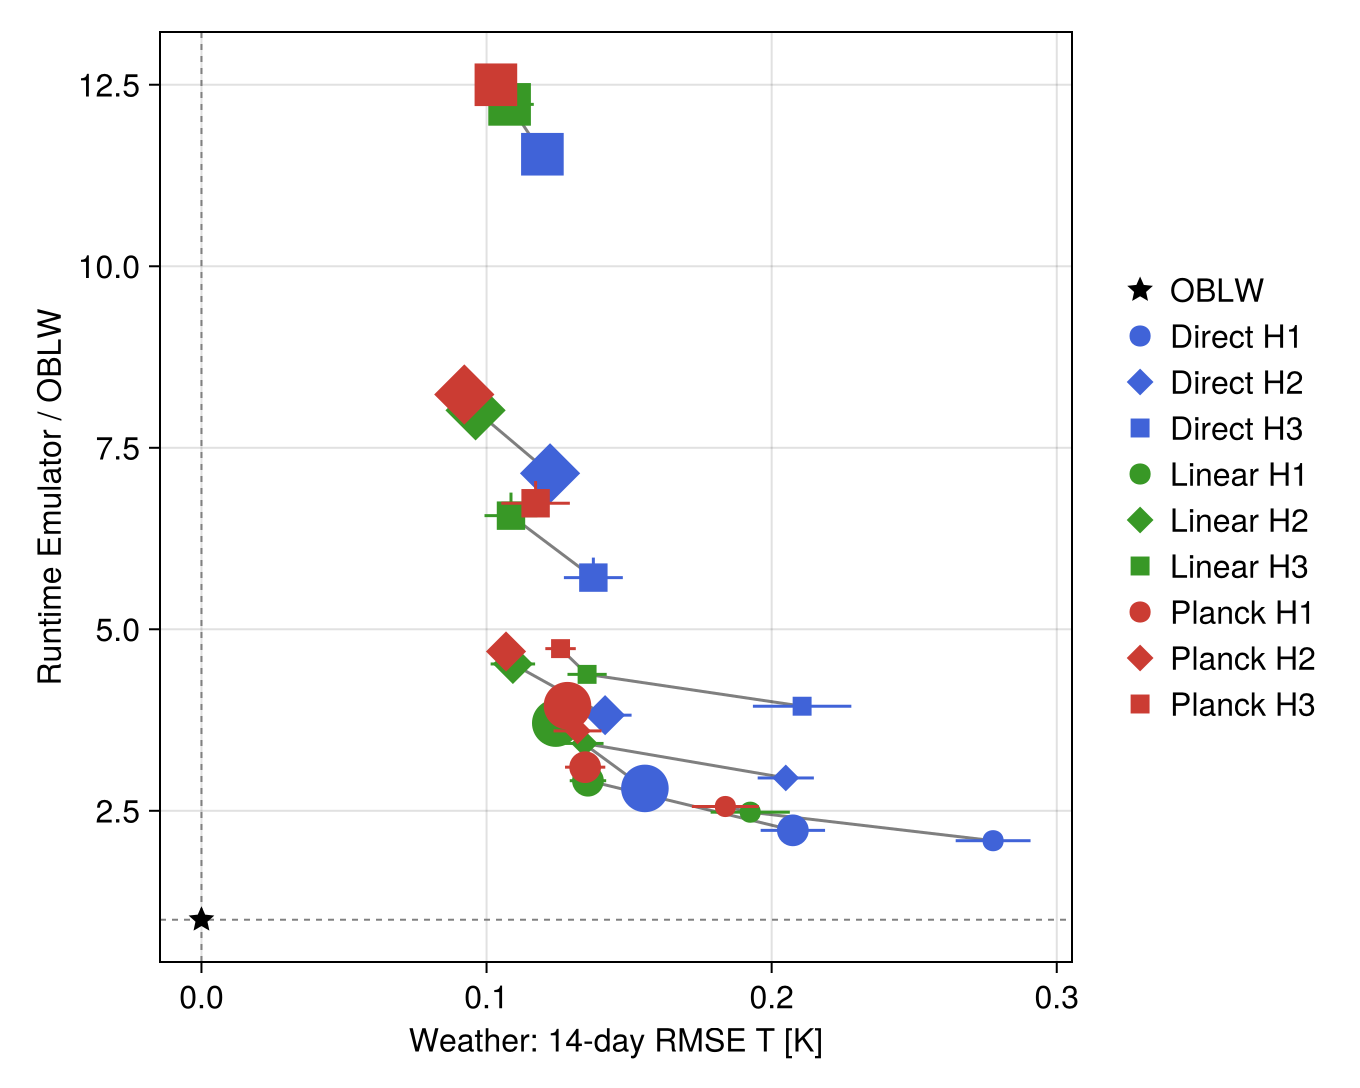

In [189]:
# Plot weather cost plane
plot_weather_cost_plane(wt, tt; looks=looks_costplane)

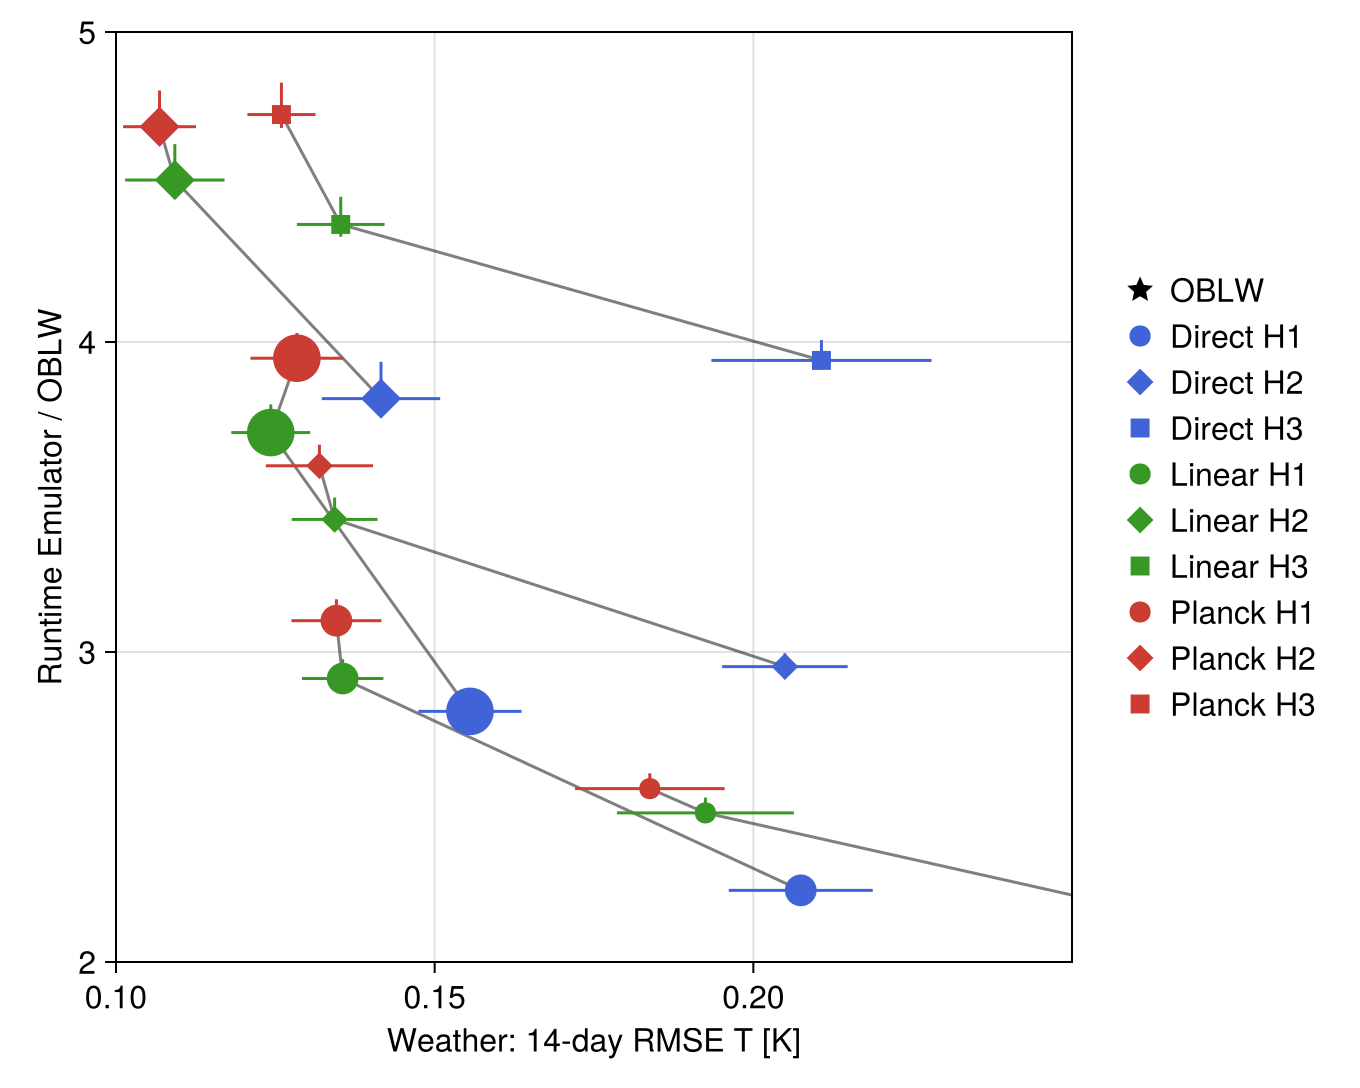

In [190]:
# Plot more zoomed in weather cost plane for better evaluation
plot_weather_cost_plane(wt, tt; looks=looks_costplane, style=(; xlim=(0.1, 0.25), ylim=(2.0, 5.0)))

In [177]:
# Define best units fur further evaluation
best_rmse = ["direct_w064_h2", "linear_w064_h2", "planck_w064_h2"]
best_timing = ["direct_w064_h1", "linear_w064_h1", "planck_w064_h1"]


# Load weather and climate rollouts
w_best_rmse = collect_rollouts(EXP, SER, best_rmse, leg = :weather)
c_best_rmse = collect_rollouts(EXP, SER, best_rmse; leg = :climate)

w_best_timing = collect_rollouts(EXP, SER, best_timing, leg = :weather)
c_best_timing = collect_rollouts(EXP, SER, best_timing; leg = :climate)

w_all = merge(w_best_rmse, w_best_timing)
c_all = merge(c_best_rmse, c_best_timing);

In [178]:
# Define looks for plots
looks = (;
    clim_noise = (; label = "OBLW pert.",  color = :black),

    direct_w064_h2 = (; label="Direct H2 W64", color=JL_BLUE),
    direct_w064_h1 = (; label="Direct H1 W64", color=:darkblue, linestyle=:dot),

    linear_w064_h2 = (; label="Linear H2 W64", color=JL_GREEN),
    linear_w064_h1 = (; label="Linear H1 W64", color=:darkgreen, linestyle=:dot),

    planck_w064_h2 = (; label="Planck H2 W64", color=JL_RED),
    planck_w064_h1 = (; label="Planck H1 W64", color=:darkred, linestyle=:dot),
);

## **3. Weather**

### 3.1. Weather Growth

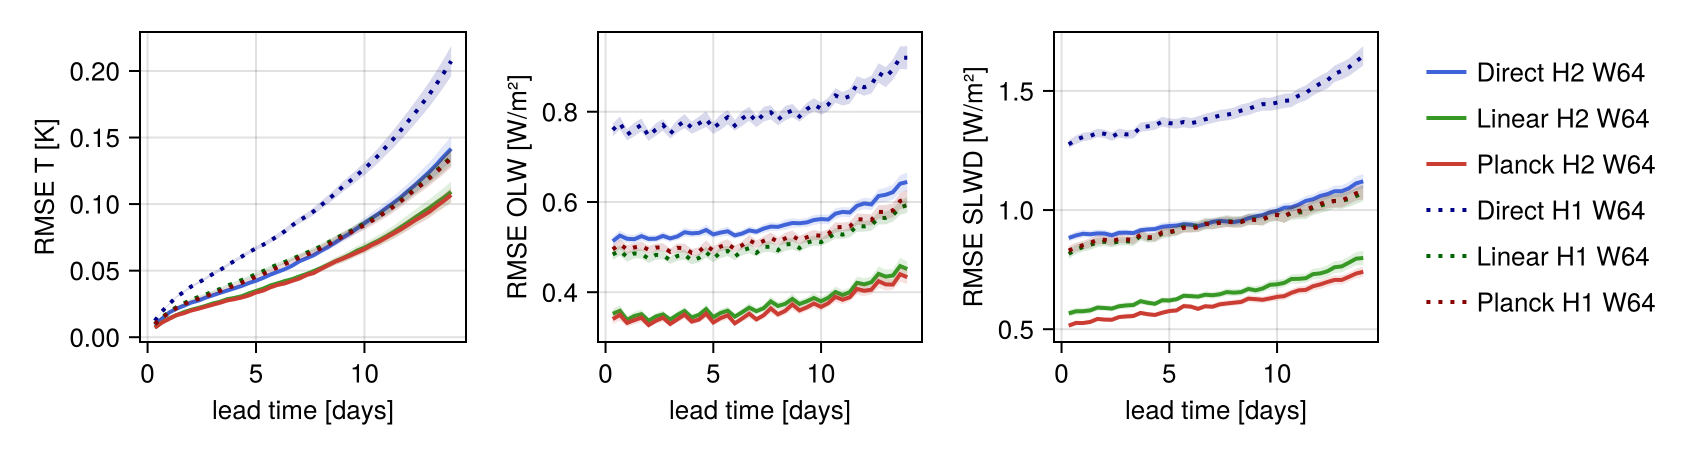

In [179]:
# Plot weather growth RMSE
plot_weather_growth(w_all, :rmse; looks)

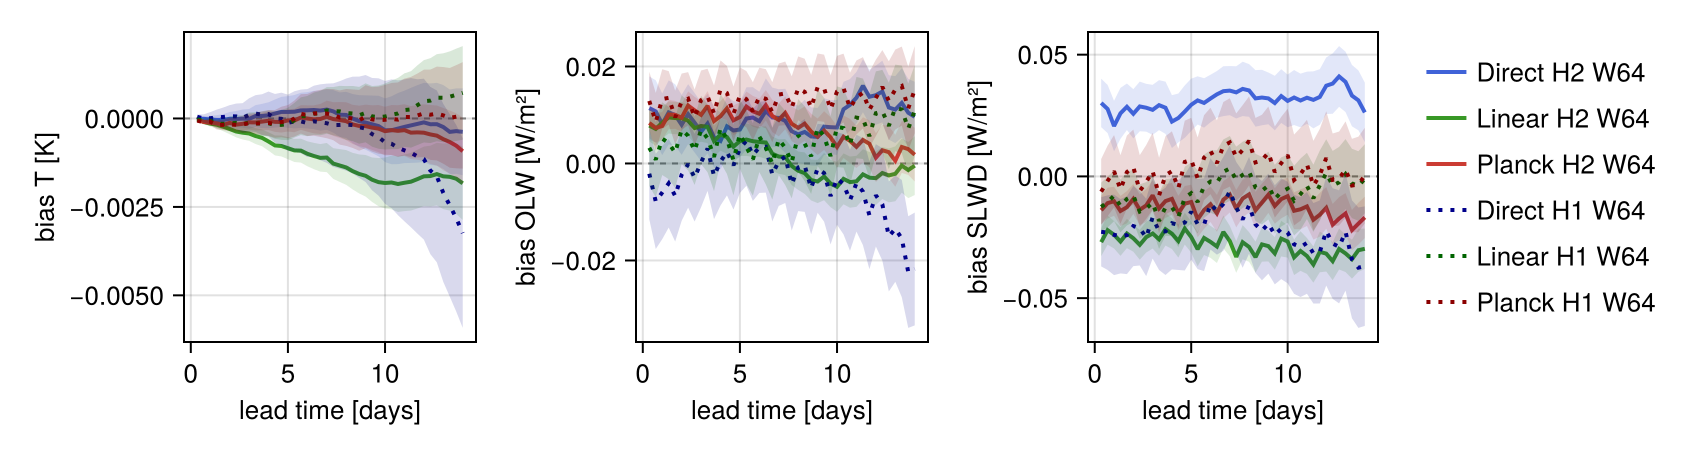

In [180]:
# Plot weather growth bias
plot_weather_growth(w_all, :bias; looks)

### 3.2. Temperature Profile

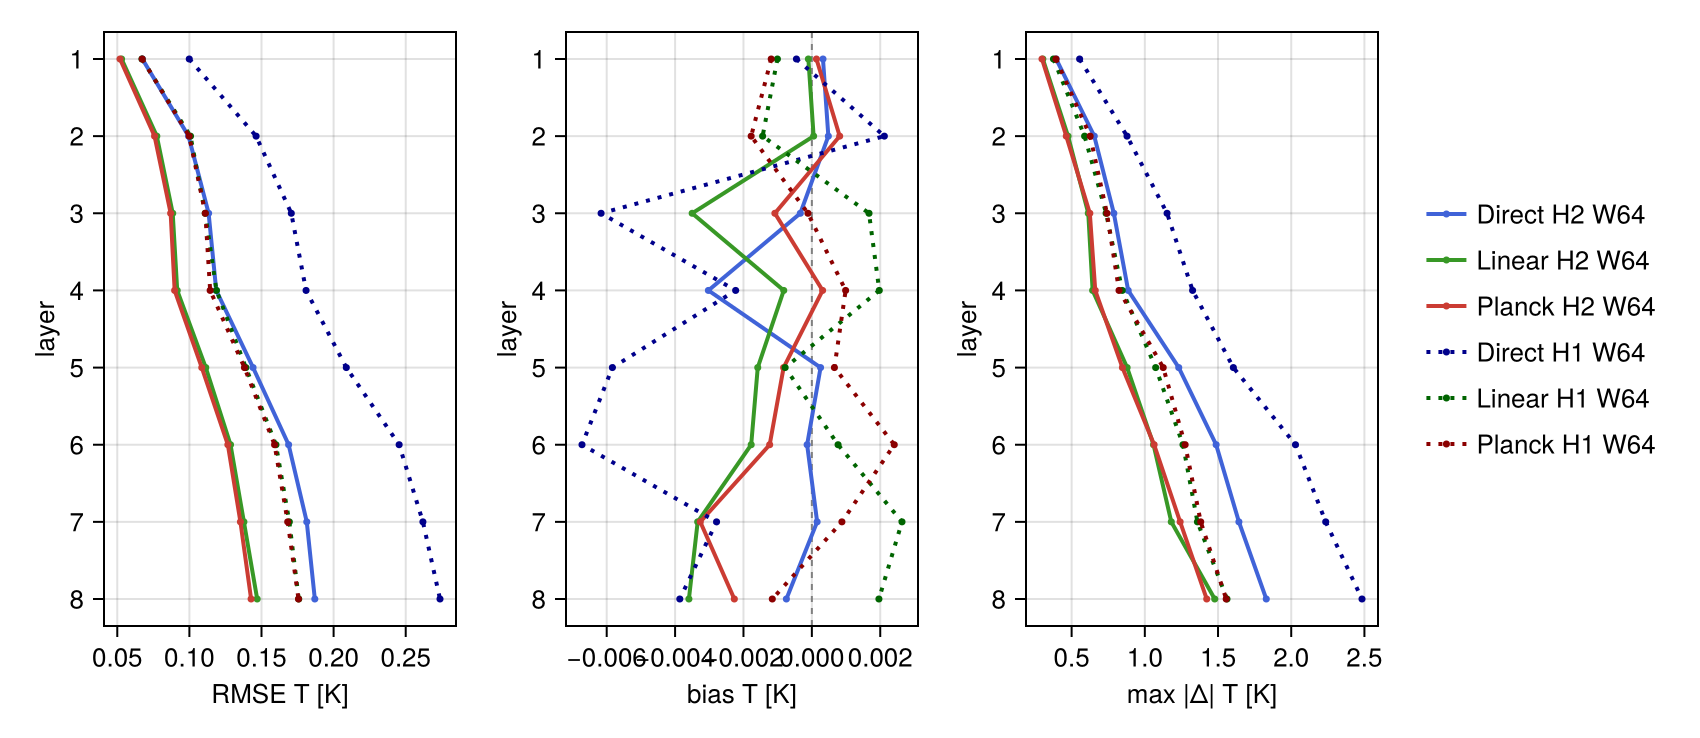

In [181]:
# Temperature profile after 14 days
plot_weather_profile(w_all, :T, 14; looks)

### 3.3. Zonal Sections

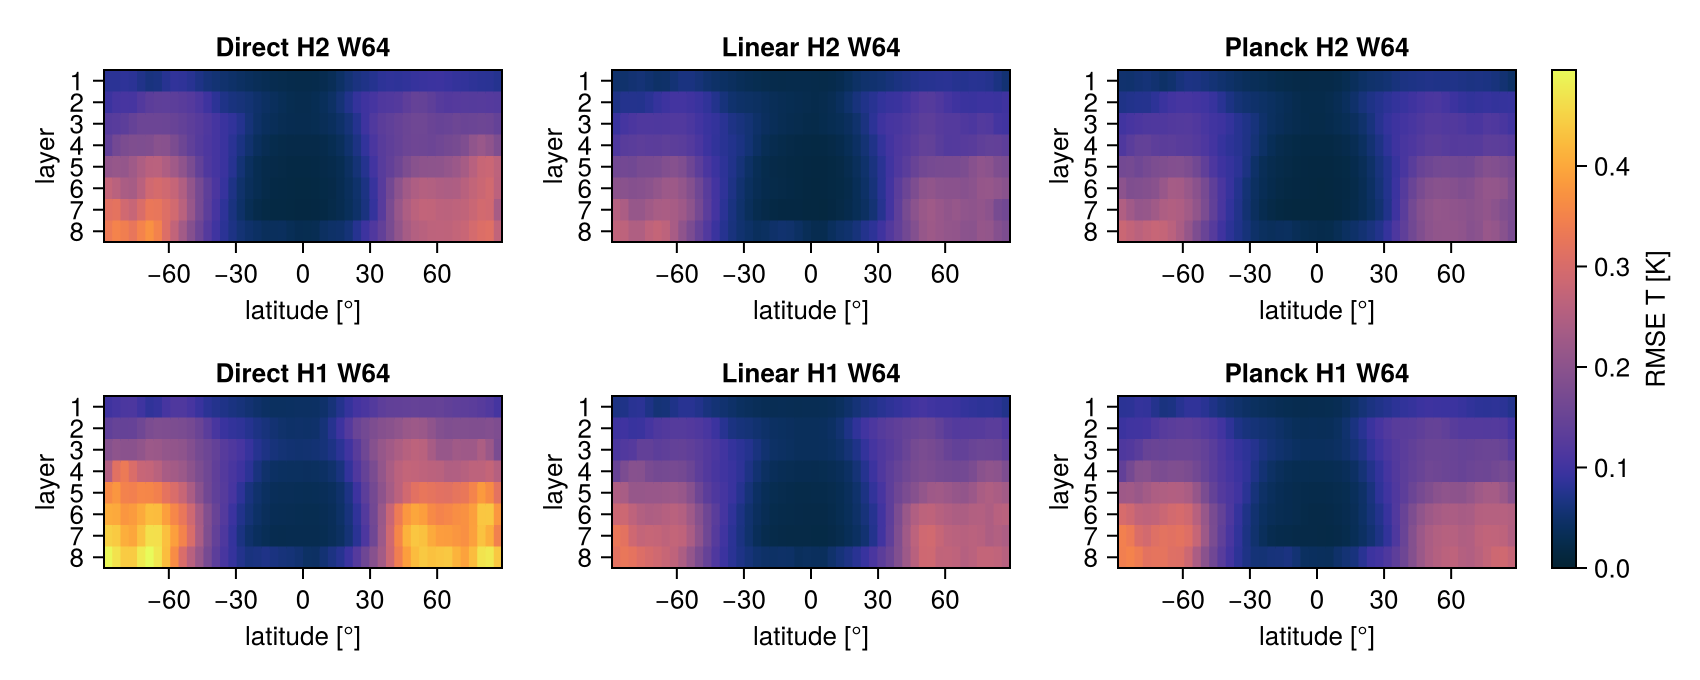

In [182]:
# Zonal temprature rmse section after 14 days
plot_weather_zonal(w_all, :T, 14, :rmse; looks)

### 3.4. LonLat Maps

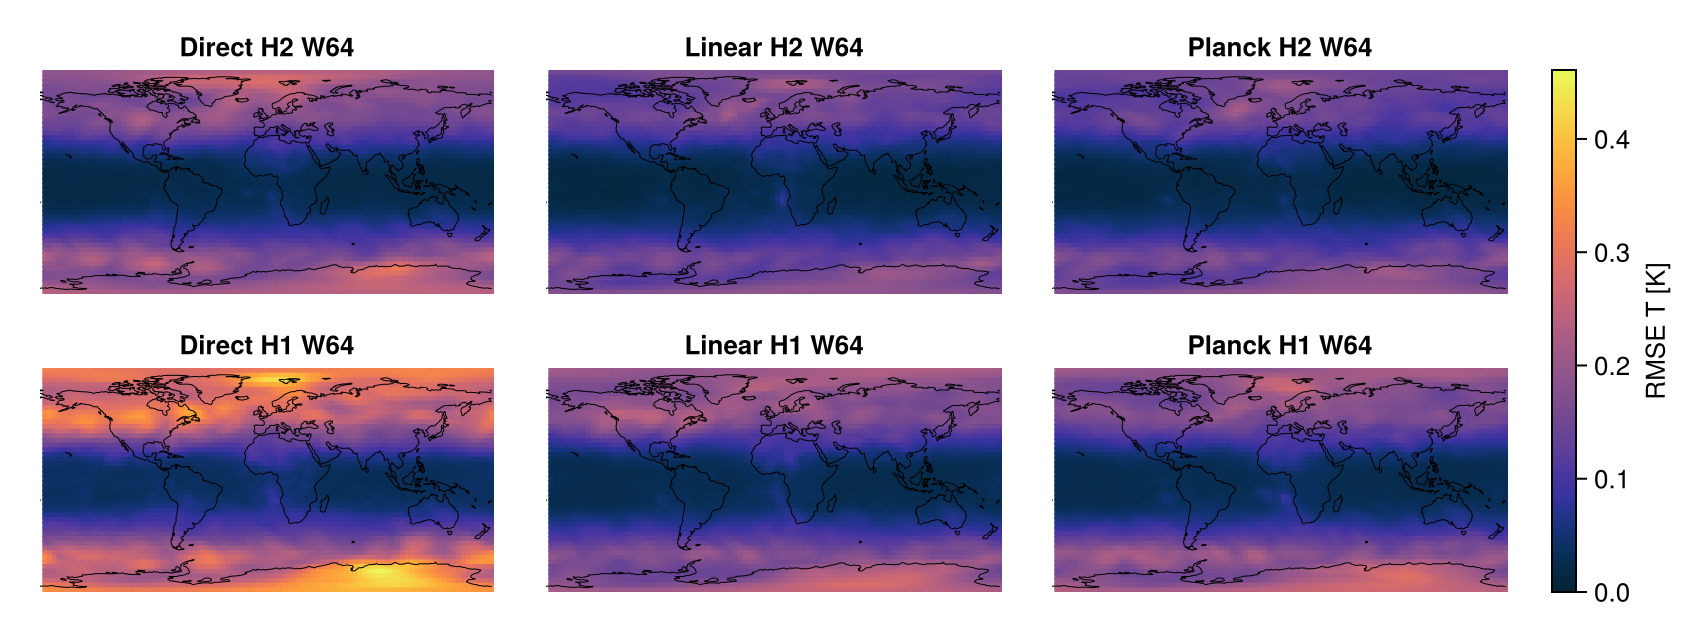

In [183]:
# LonLatMaps of rmse after 14 days
plot_weather_lonlat(w_all, :T, 14, :rmse; looks)

## **4. Climate**

In [184]:
# Merge noise to emulator rollouts
c_pert = merge((;clim_noise), c_all);

### 4.1. Climate Drift

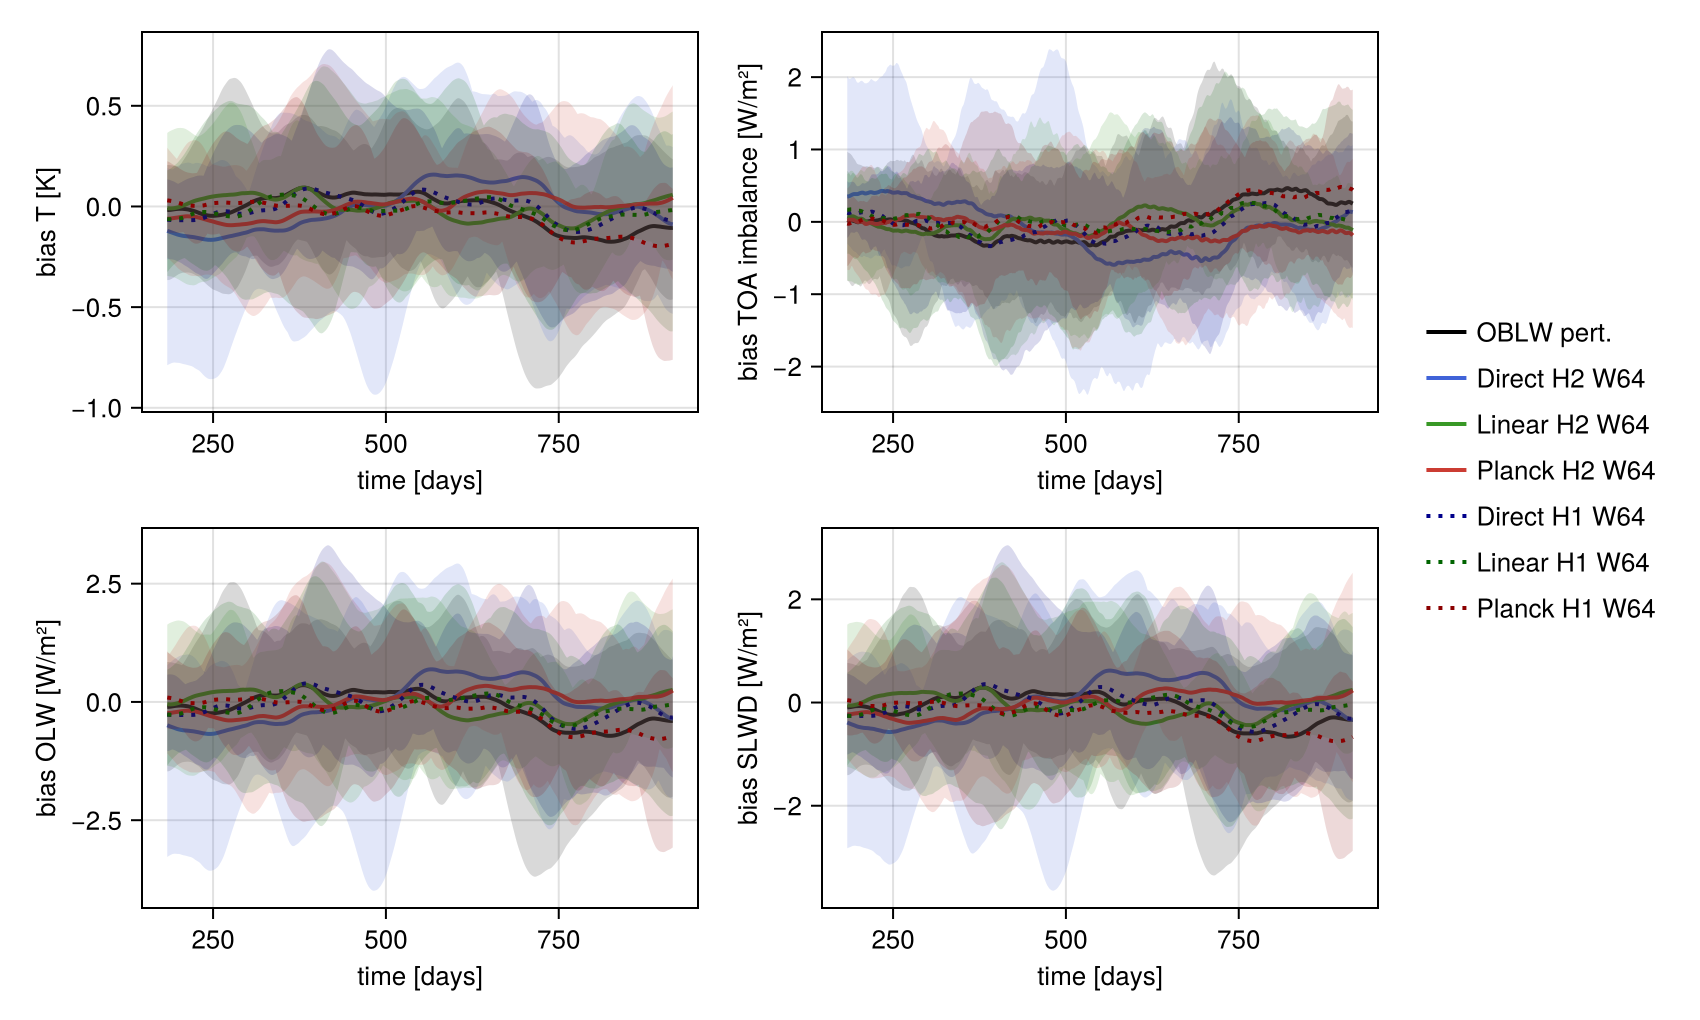

In [185]:
# Plot drift
plot_climate_drift(c_pert, clim_ref; looks, style = (;band=true))   

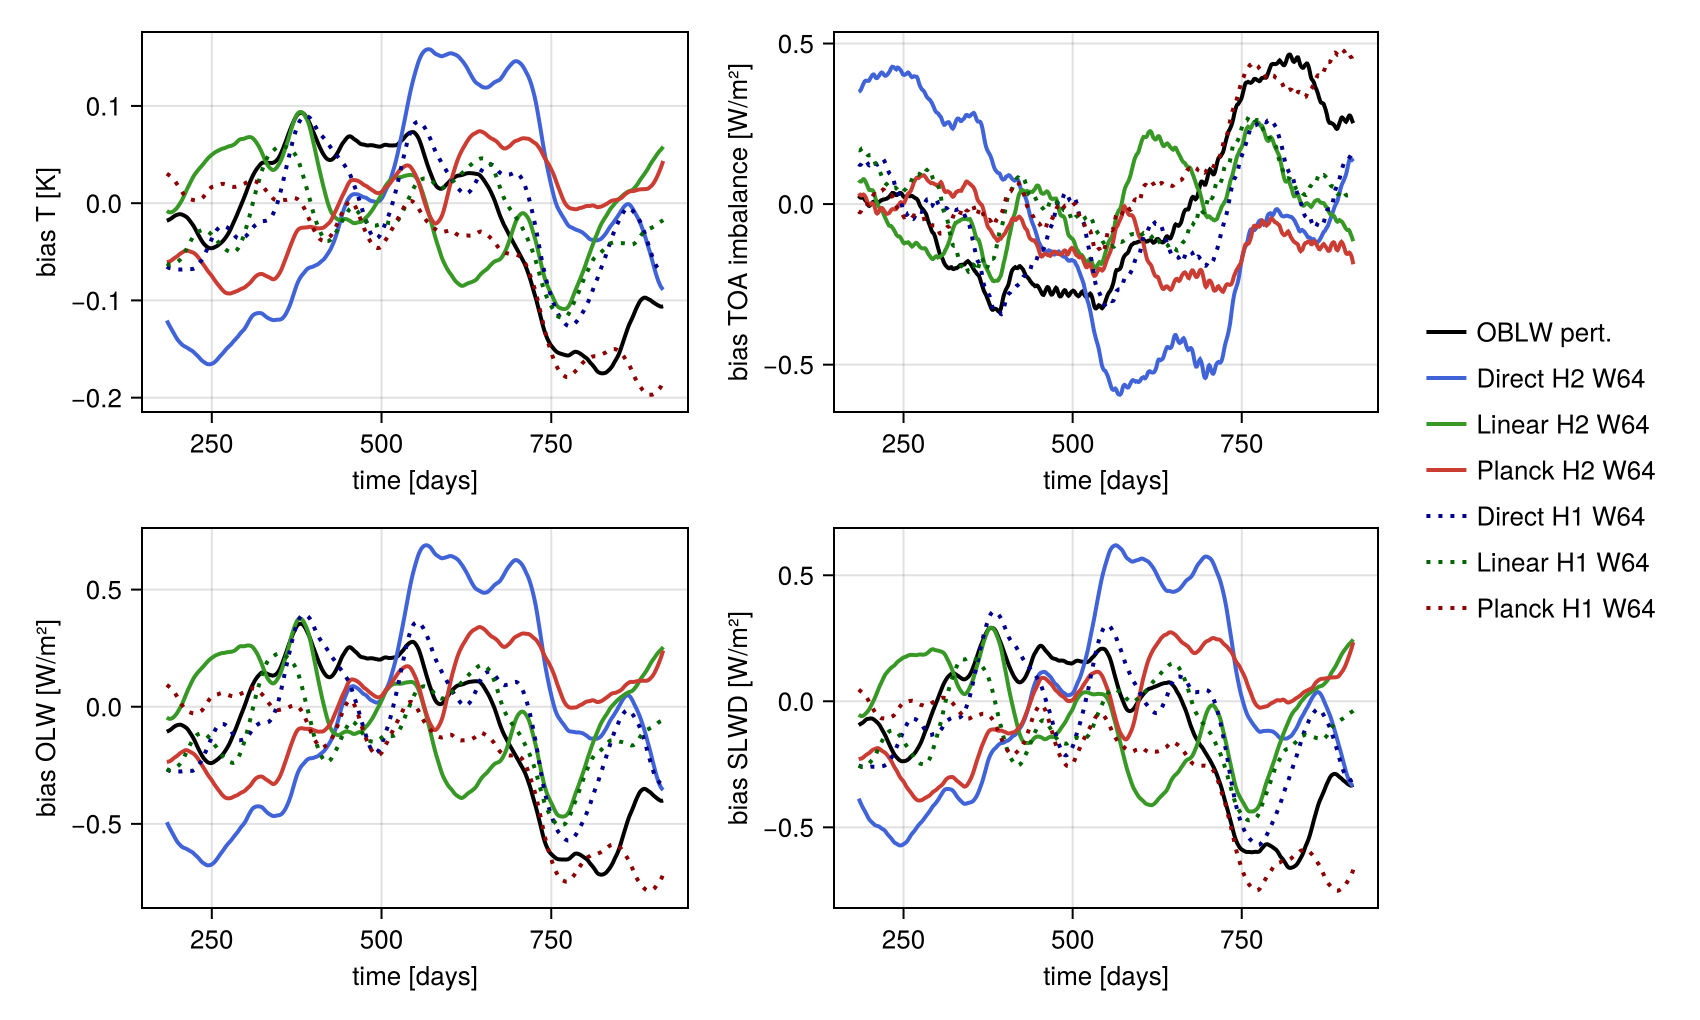

In [186]:
# Plot drift
plot_climate_drift(c_pert, clim_ref; looks, style = (;band=false))   

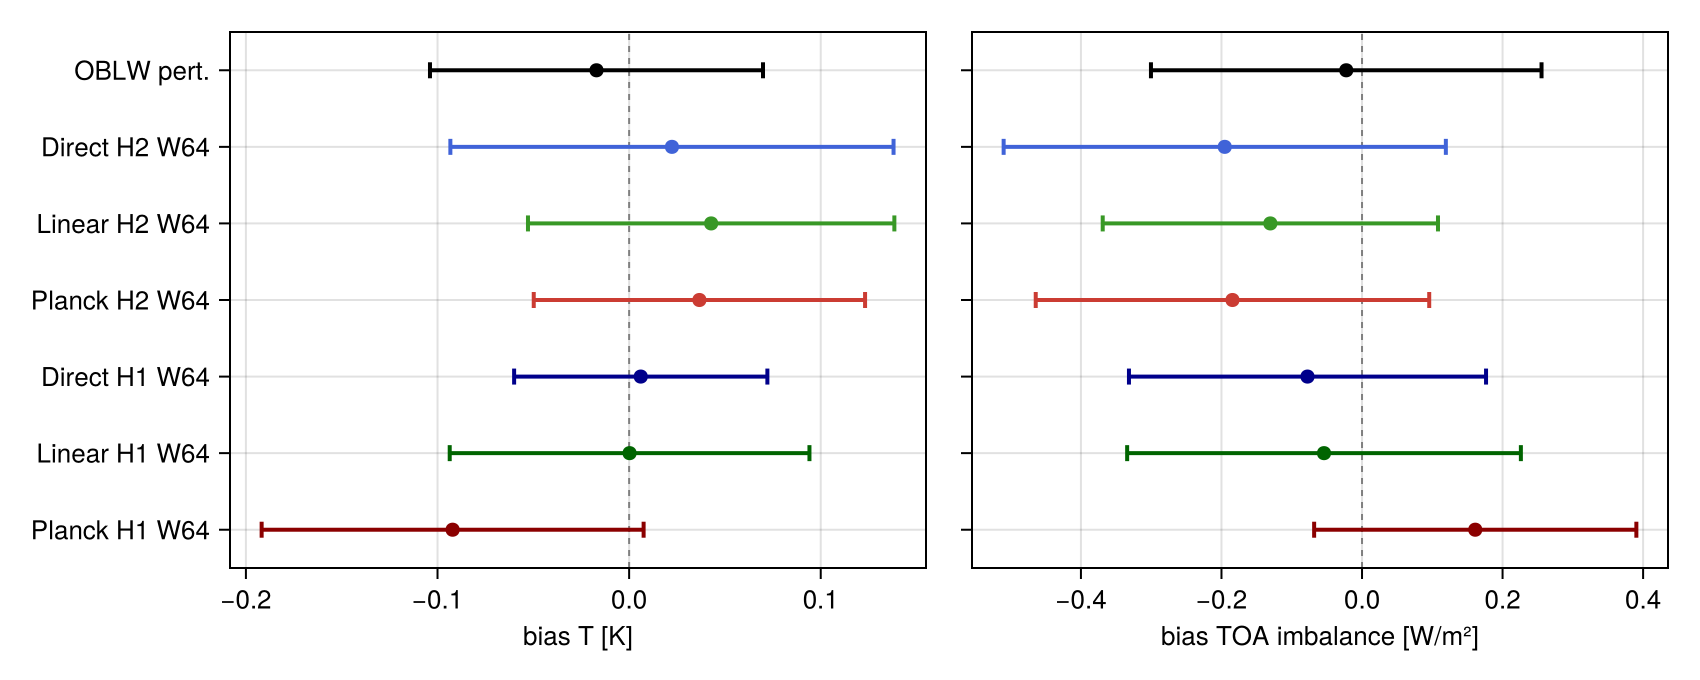

In [187]:
# Plot bias comparison
plot_climate_bias(c_pert, clim_ref; tol = nothing, looks)

### 4.2. Climate Maps

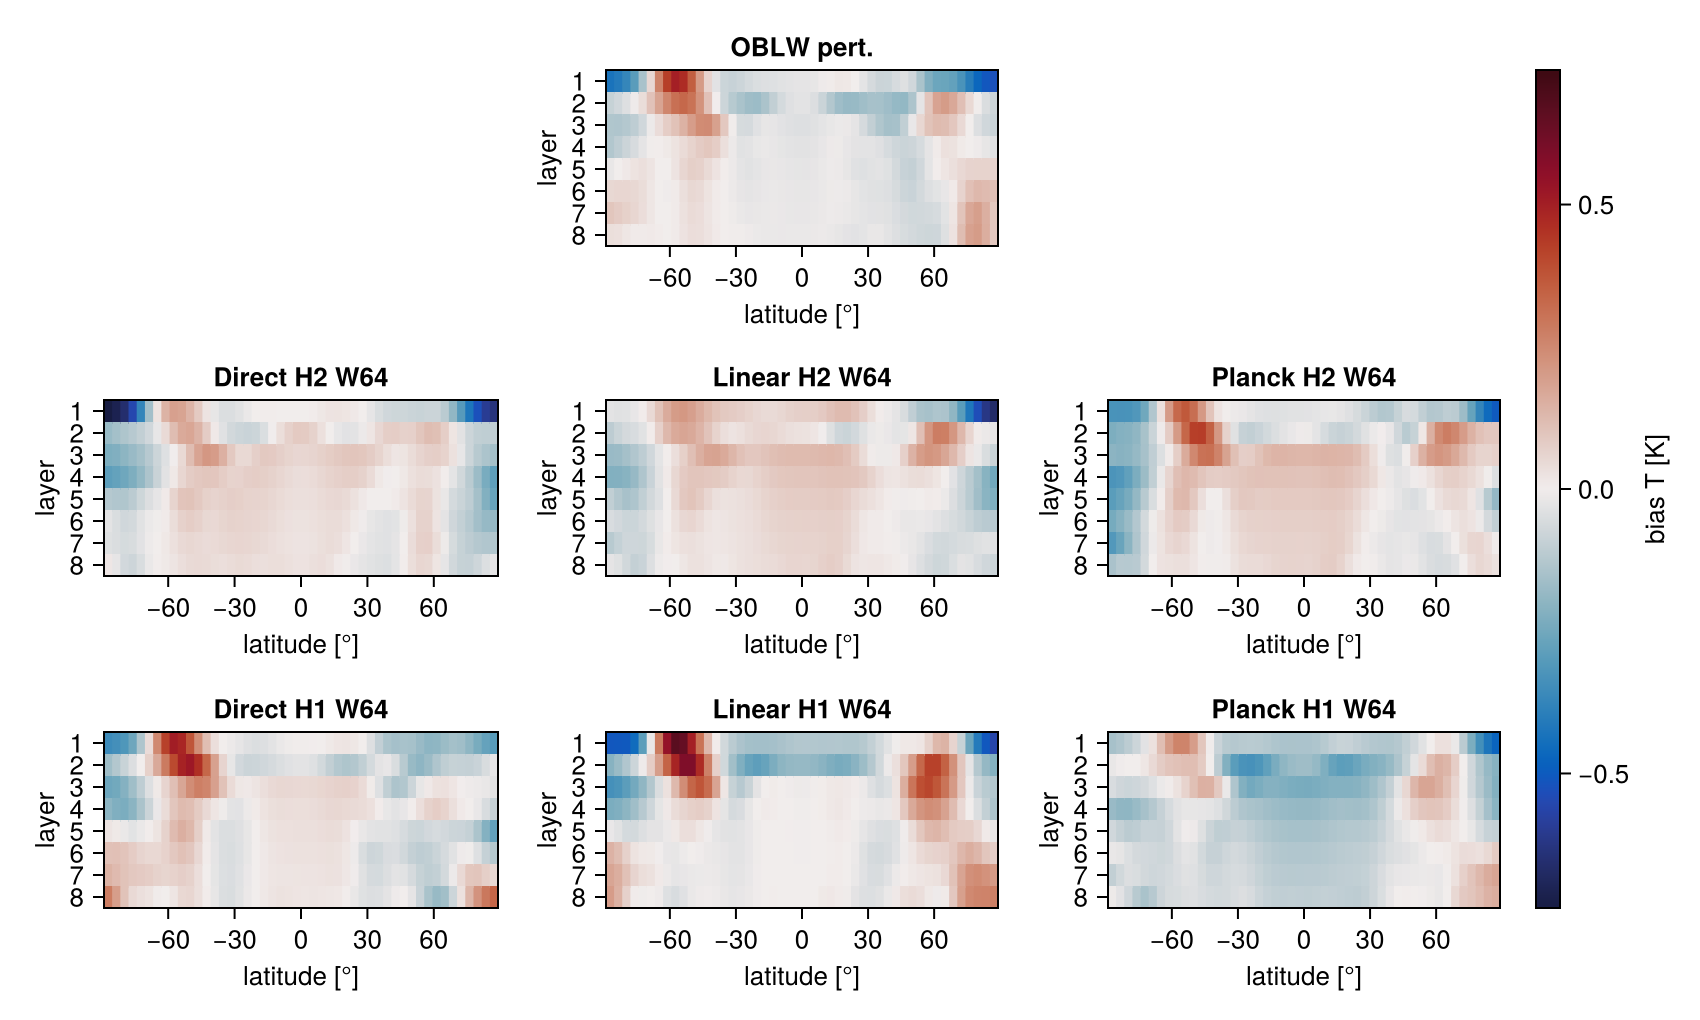

In [188]:
# Plot zonal sections 
plot_climate_zonal(c_pert, clim_ref, :T; looks, layout = [0 1 0; 1 1 1; 1 1 1])